In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
with open('./dataset/detail_dataset.txt', 'r') as files:
    for file in files:
        print(file.strip())

# Dataset Description

In this competition your task is to predict whether a passenger was transported to an alternate dimension during the Spaceship Titanic's collision with the spacetime anomaly. To help you make these predictions, you're given a set of personal records recovered from the ship's damaged computer system.

# File and Data Field Descriptions

* train.csv - Personal records for about two-thirds (~8700) of the passengers, to be used as training data.
* PassengerId - A unique Id for each passenger. Each Id takes the form gggg_pp where gggg indicates a group the passenger is travelling with and pp is their number within the group. People in a group are often family members, but not always.
* HomePlanet - The planet the passenger departed from, typically their planet of permanent residence.
* CryoSleep - Indicates whether the passenger elected to be put into suspended animation for the duration of the voyage. Passengers in cryosleep are confined to their cabins.
* Cabin - Th

In [3]:
df_train = pd.read_csv('./dataset/train.csv')
df_test = pd.read_csv('./dataset/test.csv')

display(df_train.sample(5))
display(df_test.sample(5))

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
7053,7507_02,Earth,False,E/499/S,TRAPPIST-1e,6.0,False,0.0,0.0,0.0,0.0,0.0,Joela Santin,True
5497,5863_01,Earth,False,G/950/P,55 Cancri e,0.0,False,0.0,0.0,0.0,0.0,0.0,Lawren Loverthyo,True
387,0429_01,Europa,False,A/5/S,55 Cancri e,20.0,False,2.0,10116.0,0.0,2.0,225.0,Aino Ineysive,True
2063,2209_01,Earth,False,F/433/S,TRAPPIST-1e,29.0,False,1356.0,20.0,0.0,13.0,0.0,NaN,False
1105,1169_01,Mars,NaN,F/221/S,TRAPPIST-1e,40.0,False,2357.0,0.0,9.0,0.0,0.0,Tifet Sin,False


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
4153,9016_04,Europa,True,B/345/S,55 Cancri e,28.0,False,0.0,0.0,0.0,0.0,0.0,Maiah Extraly
3099,6793_02,Europa,True,B/228/P,TRAPPIST-1e,17.0,False,0.0,0.0,0.0,0.0,0.0,Branev Wassing
3499,7600_01,Europa,True,A/91/S,55 Cancri e,25.0,False,0.0,0.0,0.0,0.0,0.0,Mesath Gloginded
1520,3265_04,Europa,False,B/119/S,TRAPPIST-1e,6.0,False,0.0,0.0,0.0,0.0,0.0,Alsham Trallect
605,1251_01,Mars,True,D/43/S,TRAPPIST-1e,29.0,False,0.0,0.0,0.0,0.0,0.0,Row Steen


In [5]:
df_train.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 3.7 MB


In [6]:
df_train.shape

(8693, 14)

In [22]:
def table_diagnose(df):
    new_df = df.copy(deep=True)
    _1 = pd.concat([new_df.isnull().sum(), new_df.nunique(), new_df.dtypes], axis=1, keys=['n null', 'n unique', 'types']).reset_index()

    _2 = new_df.nunique().reset_index()
    _3 = _2.loc[_2[0] < 5, 'index'].apply(lambda x: new_df[x].unique())

    result = pd.merge(_1, _3, left_index=True, right_index=True, how='outer')
    result.rename(columns={'index_x': 'columns', 'index_y':'unique vals'}, inplace=True)
    return result

In [23]:
# Train dataset
table_diagnose(df_train)

,columns,n null,n unique,types,unique vals
0,PassengerId,0,8693,object,NaN
1,HomePlanet,201,3,object,"[Europa, Earth, Mars, nan]"
2,CryoSleep,217,2,object,"[False, True, nan]"
3,Cabin,199,6560,object,NaN
4,Destination,182,3,object,"[TRAPPIST-1e, PSO J318.5-22, 55 Cancri e, nan]"
5,Age,179,80,float64,NaN
6,VIP,203,2,object,"[False, True, nan]"
7,RoomService,181,1273,float64,NaN
8,FoodCourt,183,1507,float64,NaN
9,ShoppingMall,208,1115,float64,NaN


In [25]:
# test dataset
table_diagnose(df_test)

,columns,n null,n unique,types,unique vals
0,PassengerId,0,4277,object,NaN
1,HomePlanet,87,3,object,"[Earth, Europa, Mars, nan]"
2,CryoSleep,93,2,object,"[True, False, nan]"
3,Cabin,100,3265,object,NaN
4,Destination,92,3,object,"[TRAPPIST-1e, 55 Cancri e, PSO J318.5-22, nan]"
5,Age,91,79,float64,NaN
6,VIP,93,2,object,"[False, nan, True]"
7,RoomService,82,842,float64,NaN
8,FoodCourt,106,902,float64,NaN
9,ShoppingMall,98,715,float64,NaN


In [19]:
numerik_df_train = df_train.select_dtypes([float, int])
kategori_df_train = df_train.select_dtypes([object, bool])

display(kategori_df_train.sample(10))
display(numerik_df_train.sample(10))

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,VIP,Name,Transported
6856,7250_01,Mars,False,F/1501/P,55 Cancri e,False,Pold Chmad,True
4842,5165_01,Earth,False,F/989/S,TRAPPIST-1e,False,Alancy Collinson,True
3983,4253_01,Earth,False,G/696/P,TRAPPIST-1e,False,Ivanne Gallandez,False
7147,7625_01,Earth,False,F/1458/S,TRAPPIST-1e,False,Gerly Burryerson,False
1689,1798_01,Earth,False,E/137/S,TRAPPIST-1e,False,Bel Mcfarley,False
2445,2624_01,Earth,False,F/542/P,TRAPPIST-1e,False,Annard Armstromez,False
8002,8560_01,Earth,True,G/1391/P,55 Cancri e,False,Glena Hahnstonsen,True
2980,3223_01,Earth,False,G/523/P,TRAPPIST-1e,False,Elany Prickmantes,False
5059,5411_01,Europa,False,B/206/S,TRAPPIST-1e,False,Alrakan Scoudelle,False
5960,6321_01,Europa,True,C/194/P,55 Cancri e,False,Batomam Pusive,True


,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
4693,15.0,0.0,0.0,0.0,0.0,0.0
606,37.0,614.0,0.0,50.0,11.0,319.0
413,22.0,0.0,0.0,0.0,0.0,0.0
3417,21.0,4.0,NaN,137.0,1640.0,455.0
5539,23.0,16.0,687.0,1.0,1.0,0.0
2145,37.0,1508.0,NaN,0.0,1.0,0.0
4590,22.0,0.0,0.0,0.0,0.0,0.0
638,15.0,1264.0,0.0,2.0,23.0,0.0
2846,16.0,NaN,0.0,0.0,0.0,0.0
2059,25.0,0.0,0.0,0.0,0.0,0.0


### 1. EDA

In [27]:
df_train[5:]

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
5,0005_01,Earth,False,F/0/P,PSO J318.5-22,44.0,False,0.0,483.0,0.0,291.0,0.0,Sandie Hinetthews,True
6,0006_01,Earth,False,F/2/S,TRAPPIST-1e,26.0,False,42.0,1539.0,3.0,0.0,0.0,Billex Jacostaffey,True
7,0006_02,Earth,True,G/0/S,TRAPPIST-1e,28.0,False,0.0,0.0,0.0,0.0,NaN,Candra Jacostaffey,True
8,0007_01,Earth,False,F/3/S,TRAPPIST-1e,35.0,False,0.0,785.0,17.0,216.0,0.0,Andona Beston,True
9,0008_01,Europa,True,B/1/P,55 Cancri e,14.0,False,0.0,0.0,0.0,0.0,0.0,Erraiam Flatic,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,Europa,False,A/98/P,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,Gravior Noxnuther,False
8689,9278_01,Earth,True,G/1499/S,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,Kurta Mondalley,False
8690,9279_01,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,Fayey Connon,True
8691,9280_01,Europa,False,E/608/S,55 Cancri e,32.0,False,0.0,1049.0,0.0,353.0,3235.0,Celeon Hontichre,False


In [31]:
df_train['Age'].describe()

count    8514.000000
mean       28.827930
std        14.489021
min         0.000000
25%        19.000000
50%        27.000000
75%        38.000000
max        79.000000
Name: Age, dtype: float64

#### Kategori umur menurut Departemen Kesehatan Republik Indonesia tahun 2009 yakni sebagai berikut :

* Masa balita usia 0 – 5 tahun
* Masa kanak-kanak usia 5 – 11 tahun
* Masa remaja awal usia 12 – 16 tahun
* Masa remaja akhir usia 17 – 25 tahun
* Masa dewasa awal usia 26 – 35 tahun
* Masa dewasa akhir usia 36 – 45 tahun
* Masa lansia awal usia 46 – 55 tahun
* Masa lansia akhir usia 56 – 65 tahun
* Masa manula usia 65 – ke atas


In [35]:
df_train['Age (cat)'] = pd.cut(
    df_train['Age'], 
    bins=[0, 5, 12, 17, 26, 36, 46, 56, 65, 100], 
    labels=['balita', 'kanak-kanak', 'remaja awal', 'remaja akhir', 'dewasa awal', 'dewasa akhir', 'lansia awal', 'lansia akhir', 'manula']
)

df_train[:5]

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,Age (cat)
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False,dewasa akhir
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True,remaja akhir
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False,lansia akhir
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False,dewasa awal
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True,remaja awal


In [139]:
by_age_cat = df_train.groupby(by='Age (cat)')
by_age_cat.size()

Age (cat)
balita           321
kanak-kanak      307
remaja awal      739
remaja akhir    2619
dewasa awal     2015
dewasa akhir    1281
lansia awal      672
lansia akhir     298
manula            84
dtype: int64

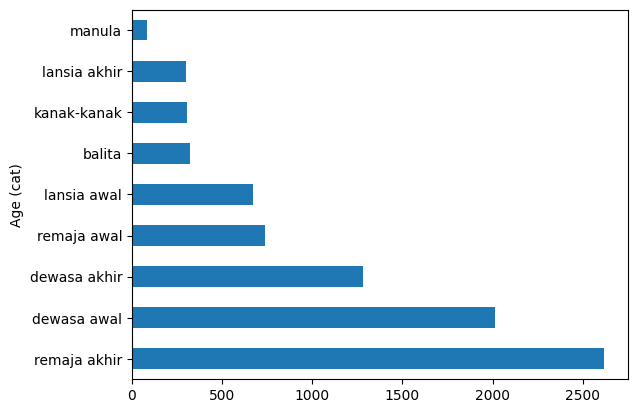

In [55]:
by_age_cat.size().sort_values(ascending=False).plot(kind='barh')
plt.show()

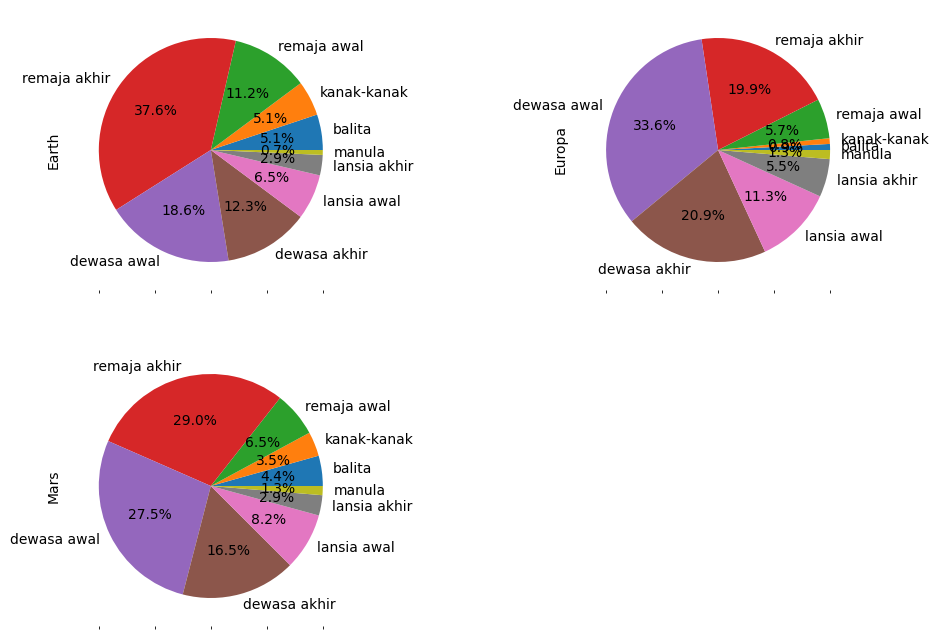

In [138]:
by_age_cat['HomePlanet'].value_counts().unstack('HomePlanet').plot(kind='pie', subplots=True, figsize=(12, 8), layout=(2, 2), autopct='%1.1f%%', legend=False)
plt.show()

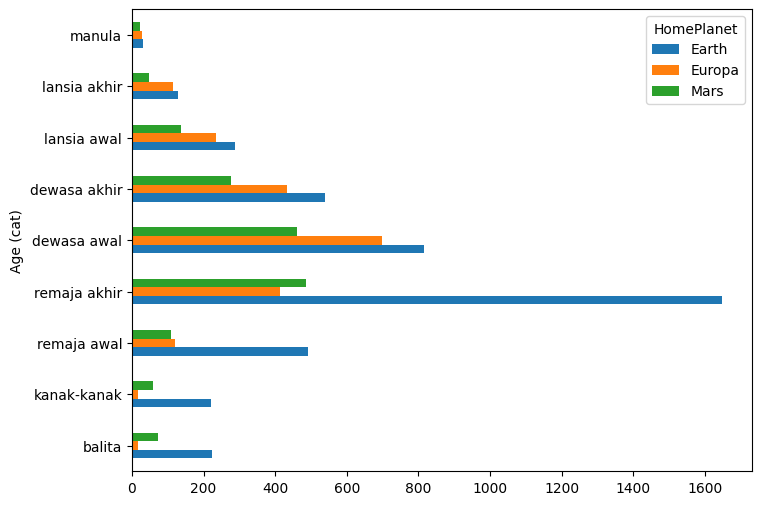

In [119]:
by_age_cat['HomePlanet'].value_counts().unstack('HomePlanet').plot(kind='barh', figsize=(8, 6))
plt.show()

HomePlanet         Earth                                Europa                \
Destination  55 Cancri e PSO J318.5-22 TRAPPIST-1e 55 Cancri e PSO J318.5-22   
Age (cat)                                                                      
balita                49            31         144           1             0   
kanak-kanak           51            13         154           8             0   
remaja awal          108            85         294          45             0   
remaja akhir         213           288        1106         196             1   
dewasa awal          114           122         557         272            13   
dewasa akhir          60            79         384         199             2   
lansia awal           36            44         201          93             2   
lansia akhir          18            23          88          39             1   
manula                 3             5          23           9             0   

HomePlanet                      Mars                            
Destination  TRAPPIST-1e 55 Cancri e PSO J318.5-22 TRAPPIST-1e  
Age (cat)                                                       
balita                17          15             0          56  
kanak-kanak            8           0             0          59  
remaja awal           73          16             2          89  
remaja akhir         214          67             6         404  
dewasa awal          398          40            17         393  
dewasa akhir         227          21            16         230  
lansia awal          132          17             5         112  
lansia akhir          73           3             0          44  
manula                18           4             2          16

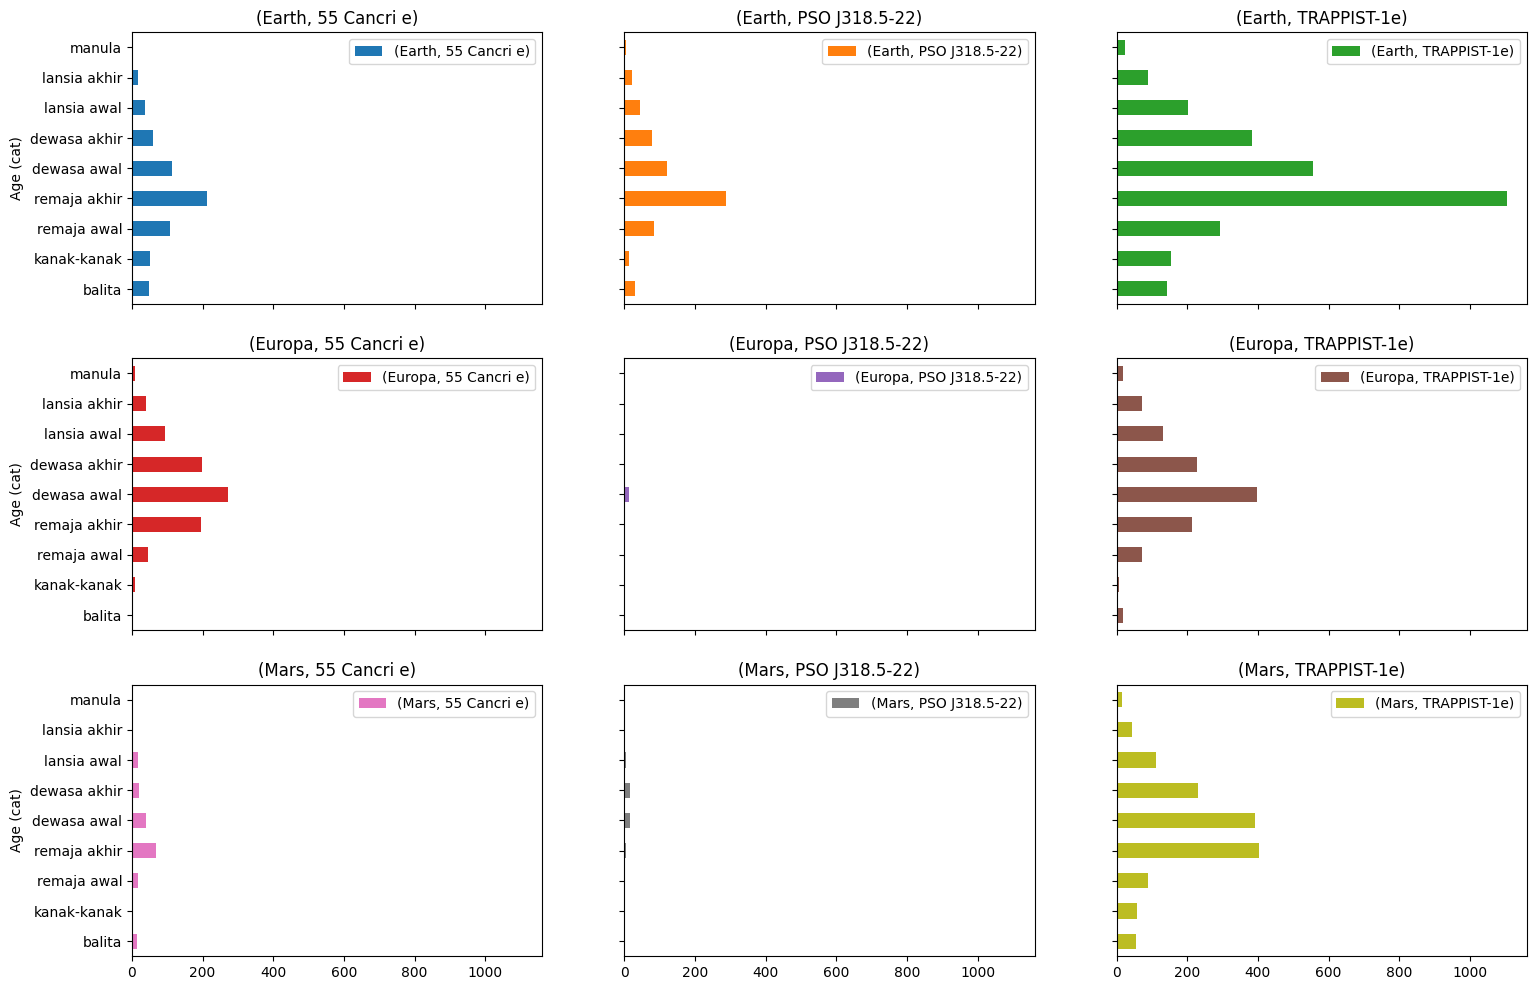

In [188]:
target_destination = by_age_cat[['HomePlanet', 'Destination']].value_counts().sort_index(level=1).unstack(['HomePlanet', 'Destination'])

display(target_destination)
target_destination.plot(kind='barh', subplots=True, layout=(3,3), figsize=(18,12), sharey=True)
plt.show()

HomePlanet
Earth     4602
Europa    2131
Mars      1759
dtype: int64

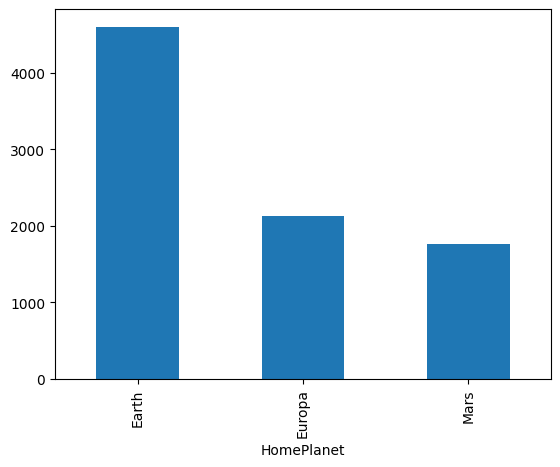

In [194]:
by_homeplanet = df_train.groupby(by='HomePlanet')

display(by_homeplanet.size())
by_homeplanet.size().plot(kind='bar')
plt.show()